# Graph Attention Network

#### Notebook Overview

This notebook demonstrates how to predict the physicochemical properties **LogS** (aqueous solubility) and **LogP** (partition coefficient) using a Graph Attention Network (GAT). We convert molecules (SMILES) into graph objects where atoms are nodes and bonds are edges, compute node features, and train a GAT to perform joint regression for both targets.

**Learning Objectives:**
- Convert SMILES strings into graph objects compatible with PyTorch Geometric
- Build node features and edge indices from RDKit molecules
- Implement a simple GAT architecture and train it for multi-target regression
- Visualize training curves and compare true vs predicted values

---

**Task:** Regression - Predict continuous values of LogS and LogP from molecular graphs using a GAT model.

**Why GAT?**
- Graph Attention Networks learn to weigh neighboring atoms differently, allowing the model to focus on the most relevant local chemical environments when predicting molecular properties.

## 1. Setting up and importing necessary libraries

In [ ]:
!pip install torch_geometric
!pip install rdkit

In [2]:
import random
import pandas as pd
import torch
import torch.nn.functional as F
from torch_geometric.data import Data, DataLoader
from torch_geometric.nn import GATConv, global_mean_pool
from rdkit import Chem
from rdkit.Chem import AllChem
from tqdm import tqdm
import matplotlib.pyplot as plt

device = {"cuda" if torch.cuda.is_available() else "cpu"}

## 2. Load Dataset

We load the ESOL-derived CSV file which contains SMILES strings and experimental values for `logS` and `logP`. This step performs basic column renaming and can be extended with quality checks:
- Verify the CSV path (`data_path`) points to the dataset in your environment.
- Inspect for missing or invalid SMILES and drop or correct them before graph conversion.
- Typical preprocessing includes removing duplicates, checking for unparsable SMILES (RDKit returns `None`), and optionally filtering extreme outliers.

Why careful loading matters: Bad SMILES or missing values break later graph construction and training. If the dataset is large, consider saving preprocessed graphs to disk for faster iterative development.

In [3]:
import requests
from io import StringIO
from rdkit.Chem import Descriptors

def load_esol_dataset():
    """Load the ESOL (Delaney) solubility dataset"""
    url = "https://raw.githubusercontent.com/deepchem/deepchem/master/datasets/delaney-processed.csv"
    response = requests.get(url)
    response.raise_for_status()

    df = pd.read_csv(StringIO(response.text))
    print(f"Loaded ESOL with {len(df)} compounds")
    print("Columns in dataset:", df.columns.tolist())
    
    # Calculate LogP since it's missing in this dataset but needed for GAT
    df['logP'] = [Descriptors.MolLogP(Chem.MolFromSmiles(s)) if Chem.MolFromSmiles(s) is not None else None for s in df['smiles']]
    
    df = df[['Compound ID', 'smiles', 'measured log solubility in mols per litre', 'logP']]
    df.columns = ['name', 'smiles', 'logS', 'logP']

    # Remove invalid SMILES
    valid_smiles = []
    for smiles in df['smiles']:
        mol = Chem.MolFromSmiles(smiles)
        valid_smiles.append(mol is not None)

    df = df[valid_smiles].reset_index(drop=True)

    return df

# Load dataset
df = load_esol_dataset()


Loaded ESOL with 1128 compounds
Columns in dataset: ['Compound ID', 'ESOL predicted log solubility in mols per litre', 'Minimum Degree', 'Molecular Weight', 'Number of H-Bond Donors', 'Number of Rings', 'Number of Rotatable Bonds', 'Polar Surface Area', 'measured log solubility in mols per litre', 'smiles']


## 3. Convert molecules to graphs and build DataLoaders

Each molecule (SMILES) is converted into a `torch_geometric.data.Data` object where:
- `x` holds node (atom) features (one row per atom),
- `edge_index` encodes graph connectivity as a 2xN_edges tensor,
- `pos` optionally stores 3D coordinates when available, and
- `y` stores target properties (here `[logS, logP]`).

Implementation notes:
- We use RDKit to parse SMILES, add explicit hydrogens, embed 3D coordinates and optimize with UFF. 3D steps improve positional features but cost more time.
- The conversion function should gracefully handle unparsable molecules (return `None`) so they can be skipped.
- Once graphs are built we shuffle and split into training and test sets, then wrap them with `DataLoader` for mini-batch training.

Performance tip: Save the constructed `Data` objects (e.g., with `torch.save`) after an initial run to avoid repeating expensive embedding/optimization when experimenting with models.

### 3.1 Node features (atom embeddings)

Our node features include basic atomic properties that are informative for physicochemical predictions. In this notebook we use:
- Atomic number (one-hot or integer),
- Degree (number of bonded neighbors),
- Formal charge,
- Hybridization state (encoded numerically),
- Explicit hydrogen count.

Extensions & ideas:
- Add aromaticity flag (atom.GetIsAromatic()), ring membership, partial charges, or one-hot encode atom types for better model expressivity.
- Consider normalizing or scaling continuous features, or using learned embeddings for categorical atomic properties.
- When using 3D coordinates (`pos`), you can incorporate distance-based edge features or radial basis encodings for geometric information.

In [4]:
def mol_to_graph(smiles, logS, logP):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None

    mol = Chem.AddHs(mol)

    AllChem.EmbedMolecule(mol, useRandomCoords=True, randomSeed=42)
    AllChem.UFFOptimizeMolecule(mol)

    Chem.Kekulize(mol, clearAromaticFlags=True)

    # Extract atom features
    atom_feats = []
    for atom in mol.GetAtoms():
        atom_feats.append([
            atom.GetAtomicNum(),               # Atomic number
            atom.GetDegree(),                  # Number of bonded neighbors
            atom.GetFormalCharge(),            # Formal charge
            atom.GetHybridization().real,      # Hybridization state
            atom.GetTotalNumHs()               # Explicit H-count
        ])
    x = torch.tensor(atom_feats, dtype=torch.float)

    # Extract edge indices
    edge_index = [[], []]
    for bond in mol.GetBonds():
        i = bond.GetBeginAtomIdx()
        j = bond.GetEndAtomIdx()
        edge_index[0] += [i, j]
        edge_index[1] += [j, i]
    edge_index = torch.tensor(edge_index, dtype=torch.long)

    # Extract 3D positions
    conf = mol.GetConformer()
    pos = torch.tensor([
        list(conf.GetAtomPosition(i))
        for i in range(mol.GetNumAtoms())
    ], dtype=torch.float)

    # Combine into a single Data object with targets
    y = torch.tensor([logS, logP], dtype=torch.float)
    data = Data(x=x, edge_index=edge_index, pos=pos, y=y)
    return data


In [5]:
dataset = []
for _, row in tqdm(df.iterrows(), total=len(df)):
    graph = mol_to_graph(row['smiles'], row['logS'], row['logP'])
    if graph is not None:
        graph.name = row['name']
        dataset.append(graph)
    
random.shuffle(dataset)
print(f'Total molecules converted to graphs: {len(dataset)}')

100%|██████████| 1128/1128 [01:20<00:00, 14.09it/s]

Total molecules converted to graphs: 1128


In [6]:
split = int(0.8 * len(dataset))
train_ds = dataset[:split]
test_ds = dataset[split:]
train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=32, shuffle=False)


C:\Users\tchai\AppData\Local\Temp\ipykernel_29404\2974258631.py:4: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
C:\Users\tchai\AppData\Local\Temp\ipykernel_29404\2974258631.py:5: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  test_loader = DataLoader(test_ds, batch_size=32, shuffle=False)


## 4. Model, optimizer and loss

We define a compact Graph Attention Network (GAT) that:
- Applies attention-based graph convolutions to compute new node embeddings (GATConv),
- Uses multiple attention heads to capture diverse neighborhood interactions,
- Aggregates node embeddings into a graph-level vector with `global_mean_pool`,
- Maps the pooled representation to two outputs (logS and logP) via a linear layer.

Why these choices:
- Attention heads let the model learn which neighboring atoms are more relevant for each prediction, improving interpretability and performance.
- Global pooling produces a fixed-size graph embedding regardless of molecule size, enabling batch training.

Optimizer & loss:
- We use Adam (fast, robust) with a small weight decay for regularization.
- For this multi-target regression problem we use Mean Squared Error (MSE) as the loss function (implemented in training/evaluation cells).

Practical tip: Monitor both training and validation MSE for each target separately to ensure neither target is being ignored.

In [7]:
class GATNet(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super(GATNet, self).__init__()
        self.conv1 = GATConv(in_channels, hidden_channels, heads=4, dropout=0.1)
        self.conv2 = GATConv(hidden_channels * 4, hidden_channels, heads=4, dropout=0.1)
        self.lin = torch.nn.Linear(hidden_channels * 4, out_channels)

    def forward(self, data):
        x, edge_index, batch = data.x, data.edge_index, data.batch
        x = F.relu(self.conv1(x, edge_index))
        x = F.relu(self.conv2(x, edge_index))
        x = global_mean_pool(x, batch)
        return self.lin(x)

# Instantiate model, optimizer
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = GATNet(in_channels=5, hidden_channels=128, out_channels=2).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-5)

## 5. Training and evaluation

Training loop overview:
1. Set the model to `train()` mode and iterate over mini-batches from the `DataLoader`.
2. Move batch data to the selected `device` (CPU/GPU).
3. Compute predictions, calculate MSE loss against targets, backpropagate (`loss.backward()`), and update weights (`optimizer.step()`).
4. Aggregate epoch loss and periodically evaluate on the validation/test set in `eval()` mode (disables dropout and other training-only layers).

Evaluation & best practices:
- Use `torch.no_grad()` during evaluation to avoid computing gradients and reduce memory usage.
- Track both overall MSE and per-target MSE for `logS` and `logP` so you can spot imbalanced learning dynamics.
- Consider learning rate schedulers and early stopping to avoid overfitting; log metrics for each epoch so you can compare runs.
- If crashes occur on large batches, lower the batch size or use gradient accumulation.

In [8]:
def train():
    model.train()
    total_loss = 0
    for batch in train_loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        pred = model(batch)

        target = batch.y.view(batch.num_graphs, -1)  # Reshape to [batch_size, 2]
        
        loss = F.mse_loss(pred, target)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * batch.num_graphs
    return total_loss / len(train_ds)

In [9]:
def evaluate(loader):
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)
            pred = model(batch) 
            target = batch.y.view(batch.num_graphs, -1)  # Reshape to [batchsize, 2]
            
            loss = F.mse_loss(pred, target)
            total_loss += loss.item() * batch.num_graphs
    return total_loss / len(loader.dataset)

## 6. Setting hyperparameters

A few hyperparameters to consider and why they matter:
- `hidden_channels`: Size of hidden node embeddings. Larger values increase capacity but may overfit on small datasets.
- `heads` in GATConv: Number of attention heads. More heads let the model capture diverse interaction patterns (costlier compute).
- `lr` (learning rate): Controls optimization step size — tune with a scheduler or grid search.
- `weight_decay`: L2 regularization to prevent overly large weights.
- `batch_size`: Trade-off between GPU memory and gradient stability.

Practical suggestion: Start with small experiments (reduced dataset or fewer epochs) to find a reasonable learning rate and model size, then scale up once the configuration is promising.

In [10]:
EPOCHS = 100

train_losses = []
test_losses = []

for epoch in range(1, EPOCHS + 1):
    train_loss = train()
    test_loss = evaluate(test_loader)
    train_losses.append(train_loss)
    test_losses.append(test_loss)
    print(f'Epoch: {epoch:03d}, Train Loss: {train_loss:.4f}, Test Loss: {test_loss:.4f}')

Epoch: 001, Train Loss: 9.0594, Test Loss: 6.1476
Epoch: 002, Train Loss: 4.9710, Test Loss: 4.5330
Epoch: 003, Train Loss: 4.0826, Test Loss: 4.1802
Epoch: 004, Train Loss: 3.9477, Test Loss: 4.0307
Epoch: 005, Train Loss: 3.7886, Test Loss: 3.9626
Epoch: 006, Train Loss: 3.7131, Test Loss: 3.9325
Epoch: 007, Train Loss: 3.7185, Test Loss: 3.9018
Epoch: 008, Train Loss: 3.6887, Test Loss: 3.8799
Epoch: 009, Train Loss: 3.6777, Test Loss: 3.8702
Epoch: 010, Train Loss: 3.6842, Test Loss: 3.8815
Epoch: 011, Train Loss: 3.6669, Test Loss: 3.8384
Epoch: 012, Train Loss: 3.6707, Test Loss: 3.8626
Epoch: 013, Train Loss: 3.6617, Test Loss: 3.8262
Epoch: 014, Train Loss: 3.6099, Test Loss: 3.8138
Epoch: 015, Train Loss: 3.6123, Test Loss: 3.7937
Epoch: 016, Train Loss: 3.6285, Test Loss: 3.7760
Epoch: 017, Train Loss: 3.5893, Test Loss: 3.7790
Epoch: 018, Train Loss: 3.5950, Test Loss: 3.7643
Epoch: 019, Train Loss: 3.6055, Test Loss: 3.7530
Epoch: 020, Train Loss: 3.5674, Test Loss: 3.7643


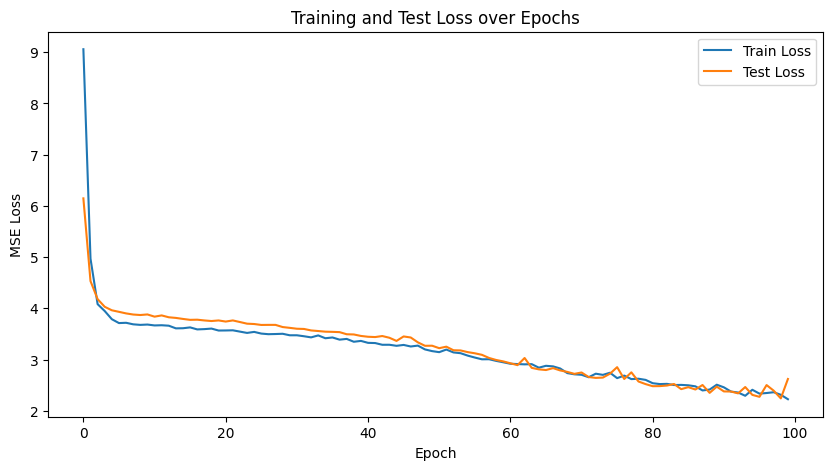

In [11]:
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train Loss')
plt.plot(test_losses, label='Test Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Training and Test Loss over Epochs')
plt.legend()
plt.show()

## 7. Evaluation: regression plots and diagnostics

After training, we evaluate predictions on the test set and visualize results:
- Scatter plots of true vs predicted values for `logS` and `logP`. Points close to the diagonal indicate good predictions.
- Report per-target MSE or MAE to quantify error in consistent units.

What to look for:
- Systematic bias (predictions consistently too high/low) — suggests a need for better features or bias correction.
- Large spread or outliers — examine molecules with large residuals to identify problematic chemotypes or dataset errors.
- Different performance between `logS` and `logP` — consider separate models or loss weighting if one target is more important.

Visualization tip: Plot residual histograms and examine a few example molecules (SMILES) where the model performs poorly to guide feature engineering.

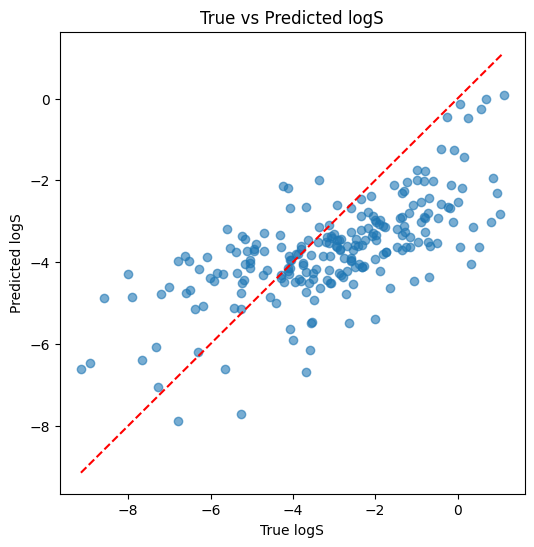

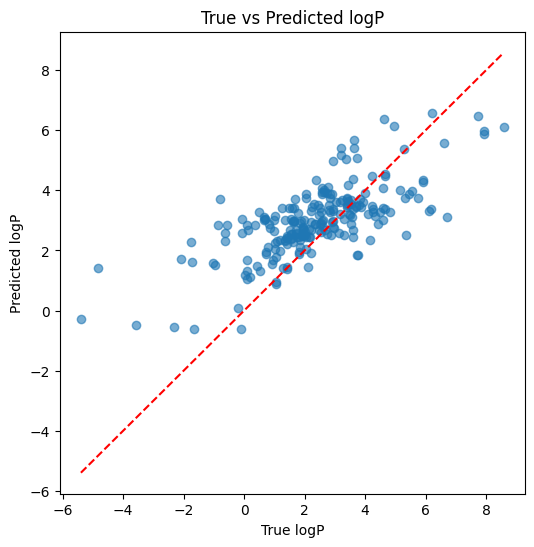

In [12]:
# evaluate the model by predicting on test set
model.eval()
all_preds = []
with torch.no_grad():
    for batch in test_loader:
        batch = batch.to(device)
        pred = model(batch)
        all_preds.append(pred.cpu())

# plot the regression results for logS
all_preds = torch.cat(all_preds, dim=0)
true_logS = torch.tensor([data.y[0] for data in test_ds])
pred_logS = all_preds[:, 0]
plt.figure(figsize=(6, 6))
plt.scatter(true_logS, pred_logS, alpha=0.6)
plt.plot([true_logS.min(), true_logS.max()], [true_logS.min(),
            true_logS.max()], 'r--')
plt.xlabel('True logS')
plt.ylabel('Predicted logS')
plt.title('True vs Predicted logS')
plt.show()

# plot the regression results for logP
true_logP = torch.tensor([data.y[1] for data in test_ds])
pred_logP = all_preds[:, 1]
plt.figure(figsize=(6, 6))
plt.scatter(true_logP, pred_logP, alpha=0.6)
plt.plot([true_logP.min(), true_logP.max()], [true_logP.min(),
            true_logP.max()], 'r--')
plt.xlabel('True logP')
plt.ylabel('Predicted logP')
plt.title('True vs Predicted logP')
plt.show()

## 8. Inspecting individual predictions

To get an intuitive sense of model behaviour we sample a small set of molecules from the test set and print their actual vs predicted `logS` and `logP`. This helps to:
- Quickly sanity-check predictions for obvious failures,
- Spot trends (e.g., consistently underpredicting lipophilic molecules), and
- Provide specific examples to guide debugging and feature improvements.

The `sample_and_predict` function prints a tabular view with molecule name, true values and model predictions. When inspecting results, consider showing the SMILES or visualizing the molecule structure for better insight.

<!-- Exercise relocated to the end of this notebook -->

In [13]:
def sample_and_predict(n):
    samples = random.sample(test_ds, min(n, len(test_ds)))
    print(f"{'Name':25s} {'Actual logS':>12s} {'Pred logS':>10s} {'Actual logP':>12s} {'Pred logP':>10s}")
    print('-' * 80)
    model.eval()
    with torch.no_grad():
        for data in samples:
            data = data.to(device)
            pred = model(data)
            
            # Target values - [logS, logP]
            actual_logS, actual_logP = data.y[0].item(), data.y[1].item()
            pred_logS, pred_logP = pred[0][0].item(), pred[0][1].item()
            
            print(f"{data.name:25s} {actual_logS:12.4f} {pred_logS:10.4f} {actual_logP:12.4f} {pred_logP:10.4f}")

sample_and_predict(10)

Name                       Actual logS  Pred logS  Actual logP  Pred logP
--------------------------------------------------------------------------------
m-Chloroiodobenzene            -3.5500    -5.4998       2.9446     4.9907
2-Nonanone                     -2.5800    -3.8908       2.9359     3.3187
1,4-Dibromobenzene             -4.0700    -5.6383       3.2116     5.4028
Anthraquinone                  -5.1900    -4.4293       2.4620     3.1956
Hexachloroethane               -3.6700    -6.6786       3.7268     5.0936
XMC                            -2.5810    -3.2613       2.0216     2.5013
Fluoromethalone                -4.0990    -3.8572       2.9233     2.9893
Thalidomide                    -2.6760    -4.2214       0.0878     2.8481
Kepone                         -5.2590    -7.7134       4.6182     6.3846
Ethyl butyrate                 -1.2800    -3.2547       2.1298     2.7002


## Exercise: Improve GAT Predictions

In [14]:
# ---
# ## Exercise: Improve GAT Predictions
# 
# In this exercise you will adapt and extend the GAT pipeline above to improve prediction quality for `logS` and `logP`. 
# Follow the steps below and submit the requested deliverables.
# ---

def perform_feature_engineering(smiles, logS, logP):
    """
    Task 1: Feature Engineering
    - Add at least two additional atom-level features to `mol_to_graph`. 
      Suggested features: aromaticity (atom.GetIsAromatic()), total valence (atom.GetTotalValence()), 
      is-in-ring (atom.IsInRing()), or atom formal charge embedding.
    - Document precisely which features you added and why you expect them to help.
    """
    # Hint: Use RDKit atom methods for new features
    # atom_feats = []
    # for atom in mol.GetAtoms():
    #     atom_feats.append([
    #         atom.GetAtomicNum(),
    #         # ADD NEW FEATURES HERE
    #     ])
    
    # YOUR CODE HERE
    pass


def run_model_experiments():
    """
    Task 2: Model Experiments
    - Run experiments changing the number of attention heads and `hidden_channels`. Try at least three combinations.
    - Optionally try adding a third GATConv layer and observe the effect.
    
    Task 3: Loss & Target Strategy
    - Compare training a single multi-output model vs two separate single-output models (one for logS, one for logP).
    - If keeping the multi-output model, experiment with loss weighting (e.g., 0.7*MSE_logS + 0.3*MSE_logP).
    """
    # Hint: Update the GATNet class or create a new one with different hyperparameters
    # model = GATNet(in_channels=..., hidden_channels=..., out_channels=...)
    
    # YOUR CODE HERE
    pass


def perform_scaffold_split(dataset):
    """
    Task 4: Data Splitting
    - Implement a scaffold split (Murcko scaffolds) for a realistic train/test split that prevents molecules 
      with the same scaffold appearing in both sets.
    - Report the difference in test performance between random split and scaffold split.
    """
    # Hint: Consider using RDKit's Murcko scaffold utilities or DeepChem's scaffold split implementations.
    # train_ds, test_ds = ...
    
    # YOUR CODE HERE
    pass


def visualize_attention_bonus(model, data):
    """
    Bonus Task:
    - Try training with attention visualization: inspect attention coefficients for a few molecules to see 
      which atoms the model focuses on when predicting logS or logP.
    """
    # YOUR CODE HERE
    pass
